In [1]:
import os

os.environ.setdefault("KERAS_BACKEND", "torch")

import keras
from keras import layers
from keras.models import Model
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [2]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [3]:
print(type(x_train))
print(type(y_train))
print(type(x_test))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [4]:
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [5]:
index = 0
x_train[index]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

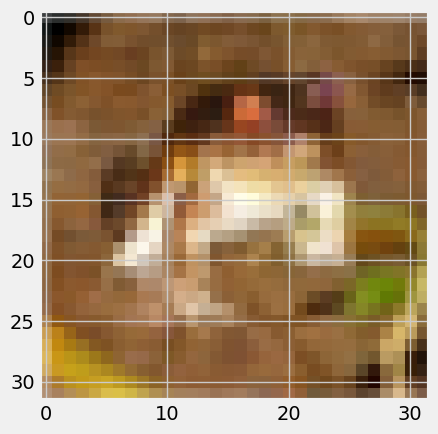

In [6]:
img = plt.imshow(x_train[index])
plt.show()

In [7]:
print('The image label is: ', y_train[index])

classification = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print('The image class is: ', classification[y_train[index][0]])

The image label is:  [6]
The image class is:  frog


In [8]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

print(y_train_one_hot)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [9]:
x_train = x_train / 255
x_test = x_test / 255

In [10]:
from sklearn.model_selection import train_test_split
from keras.src.legacy.preprocessing.image import ImageDataGenerator

idx = np.arange(len(x_train))
idx_train, idx_val = train_test_split(
    idx, test_size=0.2, random_state=42, stratify=y_train.ravel()
)
x_tr = x_train[idx_train]
x_val = x_train[idx_val]
y_tr = y_train_one_hot[idx_train]
y_val = y_train_one_hot[idx_val]

datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05,
)
train_gen = datagen.flow(x_tr, y_tr, batch_size=64, seed=42)
print("train_gen: batch_size=64, shift=0.05")


train_gen: batch_size=64, shift=0.05


In [11]:
from keras import ops

class GRN(layers.Layer):
    def build(self, input_shape):
        c = int(input_shape[-1])
        self.gamma = self.add_weight(
            name="gamma",
            shape=(1, 1, 1, c),
            initializer="zeros",
            trainable=True,
        )
        self.beta = self.add_weight(
            name="beta",
            shape=(1, 1, 1, c),
            initializer="zeros",
            trainable=True,
        )
        return super().build(input_shape)

    def call(self, x):
        gx = ops.sqrt(ops.sum(ops.square(x), axis=(1, 2), keepdims=True))
        nx = gx / (ops.mean(gx, axis=-1, keepdims=True) + keras.config.epsilon())
        return self.gamma * (x * nx) + self.beta + x


In [12]:
# Micro: depthwise 3×3 (дешевше за 5×5).
def convnext_v2_block(x, dim, name_prefix="b"):
    shortcut = x
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln1")(x)
    y = layers.DepthwiseConv2D(3, padding="same", name=f"{name_prefix}_dw")(y)
    y = layers.LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_ln2")(y)
    y = layers.Conv2D(2 * dim, 1, padding="same", name=f"{name_prefix}_pw1")(y)
    y = layers.Activation("gelu", name=f"{name_prefix}_gelu")(y)
    y = layers.Conv2D(dim, 1, padding="same", name=f"{name_prefix}_pw2")(y)
    y = GRN(name=f"{name_prefix}_grn")(y)
    return layers.Add(name=f"{name_prefix}_res")([shortcut, y])


In [13]:
keras.backend.clear_session()

inputs = layers.Input(shape=(32, 32, 3), name="input")

x = layers.Conv2D(16, 3, padding="same", use_bias=True, name="stem_conv")(inputs)
x = layers.LayerNormalization(epsilon=1e-6, name="stem_ln")(x)
x = layers.Activation("gelu", name="stem_act")(x)

x = convnext_v2_block(x, 16, name_prefix="s1")

x = layers.Conv2D(32, 2, strides=2, padding="same", name="ds1")(x)
x = layers.LayerNormalization(epsilon=1e-6, name="ds1_ln")(x)
x = layers.Activation("gelu", name="ds1_act")(x)
x = convnext_v2_block(x, 32, name_prefix="s2")

x = layers.Conv2D(48, 2, strides=2, padding="same", name="ds2")(x)
x = layers.LayerNormalization(epsilon=1e-6, name="ds2_ln")(x)
x = layers.Activation("gelu", name="ds2_act")(x)
x = convnext_v2_block(x, 48, name_prefix="s3")

x = layers.GlobalAveragePooling2D(name="gap")(x)
outputs = layers.Dense(10, activation="softmax", name="probs")(x)

model = Model(inputs, outputs, name="convnext_v2_micro_cifar")
print("model:", model.name, "| trainable params:", model.count_params())
model.summary()


model: convnext_v2_micro_cifar | trainable params: 25562


Model: "convnext_v2_micro_cifar"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │        448 │ input[0][0]       │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_ln             │ (None, 32, 32,    │         32 │ stem_conv[0][0]   │
│ (LayerNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_act            │ (None, 32, 32,    │          0 │ stem_ln[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_ln1              │ (None, 32, 32,    │         32 │ stem_act[0][0]    │
│ (LayerNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_dw               │ (None, 32, 32,    │        160 │ s1_ln1[0][0]      │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_ln2              │ (None, 32, 32,    │         32 │ s1_dw[0][0]       │
│ (LayerNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_pw1 (Conv2D)     │ (None, 32, 32,    │        544 │ s1_ln2[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_gelu             │ (None, 32, 32,    │          0 │ s1_pw1[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_pw2 (Conv2D)     │ (None, 32, 32,    │        528 │ s1_gelu[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_grn (GRN)        │ (None, 32, 32,    │         32 │ s1_pw2[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_res (Add)        │ (None, 32, 32,    │          0 │ stem_act[0][0],   │
│                     │ 16)               │            │ s1_grn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ds1 (Conv2D)        │ (None, 16, 16,    │      2,080 │ s1_res[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ds1_ln              │ (None, 16, 16,    │         64 │ ds1[0][0]         │
│ (LayerNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ds1_act             │ (None, 16, 16,    │          0 │ ds1_ln[0][0]      │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_ln1              │ (None, 16, 16,    │         64 │ ds1_act[0][0]     │
│ (LayerNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s2_dw               │ (None, 16, 16,    │        320 │ s2_ln1[0][0]      │
│ (DepthwiseConv2D)   │ 32)               │            │                 

 Total params: 25,562 (99.85 KB)

 Trainable params: 25,562 (99.85 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_delta=1e-4,
        min_lr=1e-6,
        verbose=1,
    ),
]

steps = len(train_gen)
hist = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=40,
    validation_data=(x_val, y_val),
    validation_freq=2,
    callbacks=callbacks,
)


Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 101ms/step - accuracy: 0.3041 - loss: 1.8676 - learning_rate: 0.0010
Epoch 2/40
  1/625 ━━━━━━━━━━━━━━━━━━━━ 1:05 104ms/step - accuracy: 0.4844 - loss: 1.4315

/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/home/ivan/Projects/nuralnetworks/.venv/lib/python3.14/site-packages/keras/src/callbacks/callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 119ms/step - accuracy: 0.4477 - loss: 1.5008 - val_accuracy: 0.4831 - val_loss: 1.3736 - learning_rate: 0.0010
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 104ms/step - accuracy: 0.5211 - loss: 1.3215 - learning_rate: 0.0010
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.5598 - loss: 1.2180 - val_accuracy: 0.5795 - val_loss: 1.1826 - learning_rate: 0.0010
Epoch 5/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/step - accuracy: 0.5940 - loss: 1.1429 - learning_rate: 0.0010
Epoch 6/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 121ms/step - accuracy: 0.6081 - loss: 1.0933 - val_accuracy: 0.6195 - val_loss: 1.0735 - learning_rate: 0.0010
Epoch 7/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 65s 105ms/step - accuracy: 0.6258 - loss: 1.0463 - learning_rate: 0.0010
Epoch 8/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.6401 - loss: 1.0117 - val_accuracy: 0.6299 - val_loss: 1.0304 - learning_rate: 0.0010
Epoch 9/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 105ms/st

In [15]:
model.evaluate(x_test, y_test_one_hot)[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.7789 - loss: 0.6338


0.7789000272750854

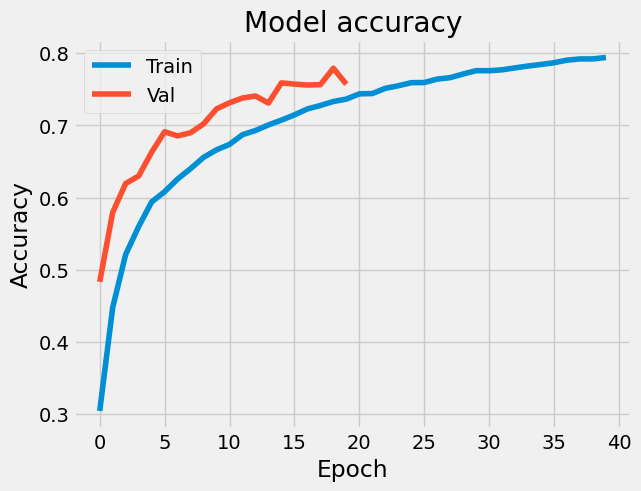

In [16]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

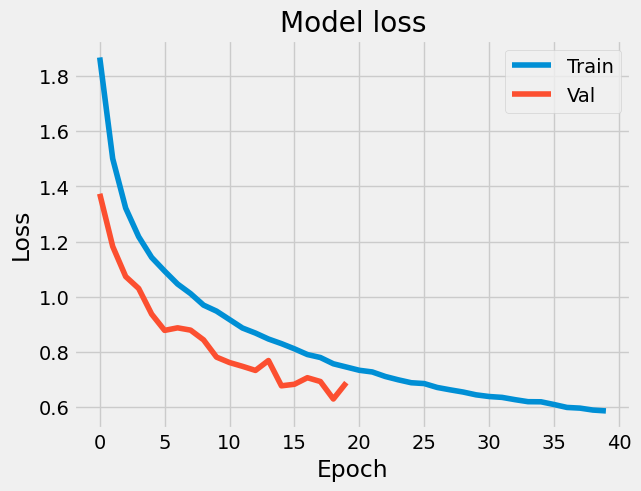

In [17]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

In [18]:
from pathlib import Path
import numpy as np
from skimage.transform import resize

IMAGES_DIR = Path("images")
EXTS = {".png", ".jpg", ".jpeg", ".webp"}
IMAGE_PATHS = sorted(p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in EXTS)


def load_rgb(path):
    arr = np.asarray(plt.imread(path), dtype=np.float64)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.ndim == 3 and arr.shape[-1] == 4:
        arr = arr[..., :3]
    elif arr.ndim == 3 and arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return arr


if not IMAGE_PATHS:
    print("No images found in", IMAGES_DIR.resolve())
else:
    x_batch = np.stack(
        [resize(load_rgb(path), (32, 32, 3), anti_aliasing=True) for path in IMAGE_PATHS]
    )
    probs = model.predict(x_batch, verbose=0)

    for path, pred in zip(IMAGE_PATHS, probs):
        order = np.argsort(-pred)[:5]
        print(path.name)
        for rank, k in enumerate(order, 1):
            print(f"  {rank}. {classification[k]}: {100 * pred[k]:.2f}%")
        print()


airplane.png
  1. airplane: 98.41%
  2. ship: 1.04%
  3. bird: 0.23%
  4. cat: 0.13%
  5. frog: 0.12%

automobile.png
  1. ship: 54.31%
  2. automobile: 38.34%
  3. truck: 5.33%
  4. airplane: 2.02%
  5. cat: 0.00%

bird.png
  1. bird: 93.23%
  2. airplane: 3.80%
  3. deer: 0.95%
  4. cat: 0.83%
  5. frog: 0.53%

cat.png
  1. cat: 56.03%
  2. frog: 26.91%
  3. deer: 7.50%
  4. horse: 3.95%
  5. bird: 3.01%

deer.png
  1. deer: 81.39%
  2. frog: 14.97%
  3. dog: 1.17%
  4. cat: 0.80%
  5. horse: 0.67%

dog.png
  1. dog: 99.87%
  2. horse: 0.06%
  3. bird: 0.04%
  4. frog: 0.02%
  5. cat: 0.01%

frog.png
  1. frog: 94.64%
  2. airplane: 2.76%
  3. cat: 1.06%
  4. bird: 1.03%
  5. deer: 0.32%

horse.png
  1. horse: 99.19%
  2. deer: 0.56%
  3. dog: 0.17%
  4. bird: 0.06%
  5. airplane: 0.02%

ship.png
  1. ship: 100.00%
  2. airplane: 0.00%
  3. deer: 0.00%
  4. truck: 0.00%
  5. bird: 0.00%

truck.png
  1. truck: 99.65%
  2. automobile: 0.35%
  3. cat: 0.00%
  4. airplane: 0.00%
  5. dog